<a href="https://colab.research.google.com/github/henrytch-usm/EEM499-Brain-Tumor-Segmentation/blob/main/Validation_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/FYP_Tumor_Segmentation/"

best_model.keras	     prediction_sample_3.png
prediction_active_tumor.png  prediction_sample.png
prediction_sample_1.png      thesis_prediction_visual.png
prediction_sample_2.png      training_curves.png


In [ ]:
import os

print("🔍 Checking what's already available in this runtime...\n")

# 1. Check if Drive is mounted
drive_mounted = os.path.exists('/content/drive/MyDrive')
print(f"Drive mounted          : {'✅ Yes' if drive_mounted else '❌ No — will need to mount'}")

# 2. Check if local BraTS data already exists (survived from a previous cell this session)
data_path = '/content/brats_local_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
data_exists = os.path.exists(data_path)
if data_exists:
    n_patients = len(os.listdir(data_path))
    print(f"Local BraTS data        : ✅ Found — {n_patients} patient folders already extracted")
else:
    print(f"Local BraTS data        : ❌ Not found — will need to copy + unzip from Drive (slowest step)")

# 3. Check if the zip is at least already sitting in local storage (skips the Drive copy, still need unzip)
local_zip_path = "/content/BraTS2020_Full.zip"
zip_exists = os.path.exists(local_zip_path)
print(f"Local zip file          : {'✅ Found — can skip Drive copy, still need to unzip' if zip_exists else '❌ Not found'}")

# 4. Check if the trained model checkpoint exists in Drive
checkpoint_path = '/content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras'
checkpoint_exists = os.path.exists(checkpoint_path) if drive_mounted else False
print(f"Saved model checkpoint  : {'✅ Found' if checkpoint_exists else '❌ Not found (check Drive mount first if this says No)'}")

# 5. Check if val_ids / val_dataset_final survived in memory (unlikely after reset, but worth checking)
val_ids_exists = 'val_ids' in dir()
val_ds_exists = 'val_dataset_final' in dir()
print(f"val_ids in memory       : {'✅ Yes — skip Cell 2' if val_ids_exists else '❌ No — need to rebuild'}")
print(f"val_dataset_final ready : {'✅ Yes — skip Cell 3' if val_ds_exists else '❌ No — need to rebuild'}")

print("\n📋 Summary:")
if data_exists and checkpoint_exists:
    print("   You can likely skip the slow re-copy/unzip step. Go straight to rebuilding val_ids and reloading the model.")
elif checkpoint_exists and not data_exists:
    print("   Model is safe, but data needs re-extracting — budget time for Cell 1 (copy + unzip).")
elif not checkpoint_exists:
    print("   ⚠️ Model checkpoint not found — double check the Drive path before proceeding, since nothing else matters if this is missing.")

🔍 Checking what's already available in this runtime...

Drive mounted          : ✅ Yes
Local BraTS data        : ❌ Not found — will need to copy + unzip from Drive (slowest step)
Local zip file          : ❌ Not found
Saved model checkpoint  : ✅ Found
val_ids in memory       : ❌ No — need to rebuild
val_dataset_final ready : ❌ No — need to rebuild

📋 Summary:
   Model is safe, but data needs re-extracting — budget time for Cell 1 (copy + unzip).


In [ ]:
import os

data_path = '/content/brats_local_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

drive_zip_path = "/content/drive/MyDrive/BraTS2020_Full.zip"
local_zip_path = "/content/BraTS2020_Full.zip"
local_extract_folder = "/content/brats_local_data/"

print("Copying zip from Drive to local storage...")
!cp "{drive_zip_path}" "{local_zip_path}"

print("Unzipping dataset to local directory...")
!unzip -n -q "{local_zip_path}" -d "{local_extract_folder}"
print("✅ Done.")

Copying zip from Drive to local storage...
Unzipping dataset to local directory...
✅ Done.


In [ ]:
import os
from sklearn.model_selection import train_test_split

DATA_PATH = data_path
VAL_SPLIT = 0.2
RANDOM_SEED = 42

def get_patient_ids(data_path):
    all_entries = sorted(os.listdir(data_path))
    valid_ids = []
    for entry in all_entries:
        patient_path = os.path.join(data_path, entry)
        if not os.path.isdir(patient_path):
            continue
        required_files = [f'{entry}_t1.nii', f'{entry}_t1ce.nii', f'{entry}_t2.nii',
                           f'{entry}_flair.nii', f'{entry}_seg.nii']
        if all(os.path.exists(os.path.join(patient_path, f)) for f in required_files):
            valid_ids.append(entry)
    return valid_ids

patient_ids = get_patient_ids(DATA_PATH)
train_ids, val_ids = train_test_split(patient_ids, test_size=VAL_SPLIT, random_state=RANDOM_SEED)
print(f"✅ Rebuilt val_ids: {len(val_ids)} patients")

✅ Rebuilt val_ids: 74 patients


In [ ]:
import numpy as np
import nibabel as nib
import tensorflow as tf

def normalize_volume(volume):
    vol_min, vol_max = np.min(volume), np.max(volume)
    if vol_max == 0:
        return volume.astype(np.float16)
    return ((volume - vol_min) / (vol_max - vol_min)).astype(np.float16)

def remap_labels(seg_volume):
    remapped = seg_volume.copy()
    remapped[remapped == 4] = 3
    return remapped.astype(np.uint8)

SLICE_START = 0
SLICE_END = 155

def load_patient_slices(patient_id, data_path, slice_start=SLICE_START, slice_end=SLICE_END):
    patient_path = os.path.join(data_path, patient_id)
    t1    = nib.load(os.path.join(patient_path, f'{patient_id}_t1.nii')).get_fdata()
    t1ce  = nib.load(os.path.join(patient_path, f'{patient_id}_t1ce.nii')).get_fdata()
    t2    = nib.load(os.path.join(patient_path, f'{patient_id}_t2.nii')).get_fdata()
    flair = nib.load(os.path.join(patient_path, f'{patient_id}_flair.nii')).get_fdata()
    seg   = nib.load(os.path.join(patient_path, f'{patient_id}_seg.nii')).get_fdata()

    t1, t1ce = normalize_volume(t1), normalize_volume(t1ce)
    t2, flair = normalize_volume(t2), normalize_volume(flair)
    seg = remap_labels(seg)

    X_slices, Y_slices = [], []
    for idx in range(slice_start, slice_end):
        x = np.stack([t1[:, :, idx], t1ce[:, :, idx], t2[:, :, idx], flair[:, :, idx]], axis=-1)
        y = seg[:, :, idx]
        X_slices.append(x)
        Y_slices.append(y)
    return np.array(X_slices, dtype=np.float16), np.array(Y_slices, dtype=np.uint8)

def patient_generator(patient_list, data_path):
    for pid in patient_list:
        try:
            X, Y = load_patient_slices(pid, data_path)
            yield X, Y
        except Exception as e:
            pass

N_CLASSES = 4
BATCH_SIZE = 4

@tf.function
def one_hot_encode(image, mask):
    mask_one_hot = tf.one_hot(tf.cast(mask, tf.int32), depth=N_CLASSES)
    return image, mask_one_hot

val_raw = tf.data.Dataset.from_generator(
    lambda: patient_generator(val_ids, DATA_PATH),
    output_signature=(
        tf.TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float16),
        tf.TensorSpec(shape=(None, 240, 240), dtype=tf.uint8)
    )
)

val_dataset_final = (
    val_raw
    .unbatch()
    .map(one_hot_encode, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
print("✅ val_dataset_final rebuilt.")

✅ val_dataset_final rebuilt.


In [ ]:
from tensorflow.keras.models import load_model

def dice_coef_per_class(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, N_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, N_CLASSES])
    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice_per_class)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef_per_class(y_true, y_pred)

def combined_loss(y_true, y_pred):
    d_loss = dice_loss(y_true, y_pred)
    cce_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return d_loss + tf.reduce_mean(cce_loss)

checkpoint_path = '/content/drive/MyDrive/FYP_Tumor_Segmentation/best_model.keras'
model = load_model(checkpoint_path, custom_objects={
    'combined_loss': combined_loss,
    'dice_coef_per_class': dice_coef_per_class
})
print("✅ Model reloaded.")

✅ Model reloaded.


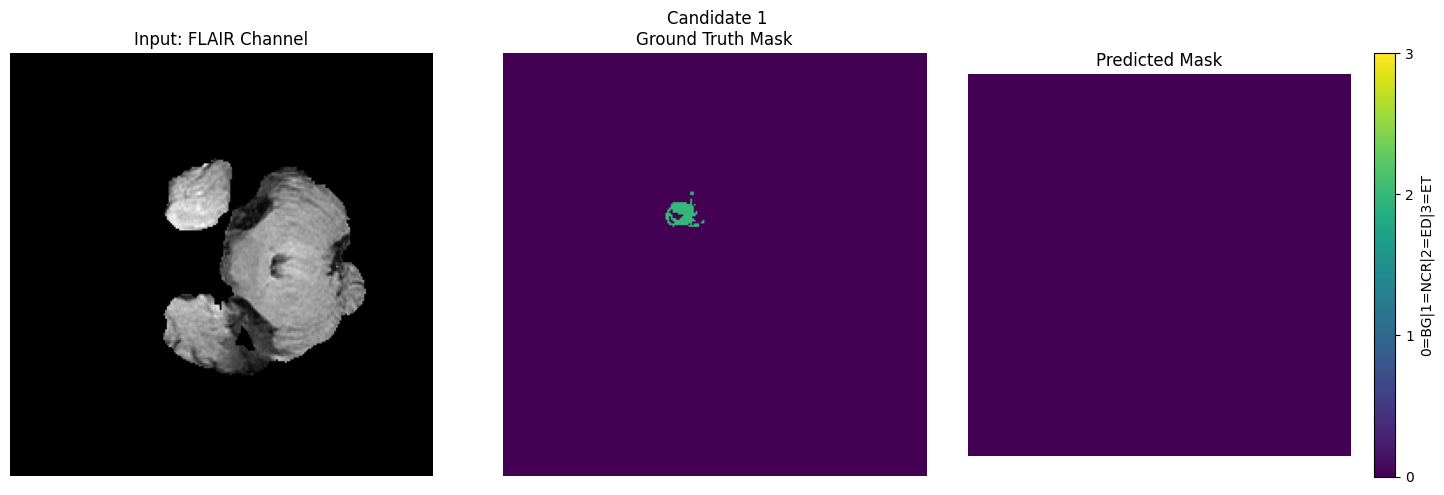


📊 Per-class Dice Scores (Candidate 1):
   Class 0 (Background               ): Dice = 0.9984
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 0.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


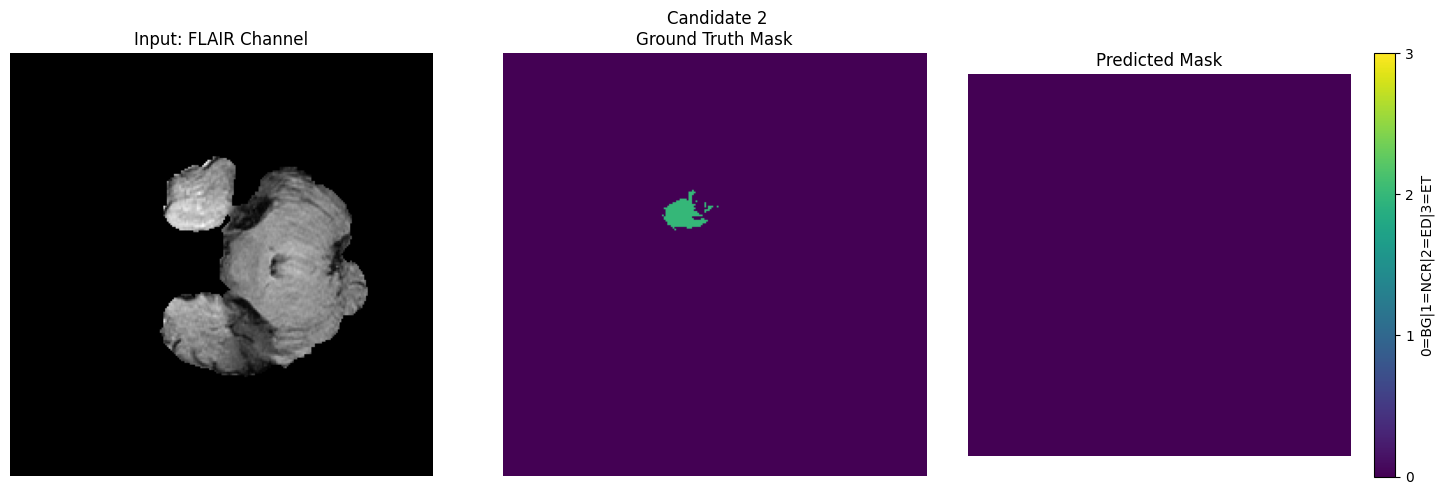


📊 Per-class Dice Scores (Candidate 2):
   Class 0 (Background               ): Dice = 0.9974
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 0.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


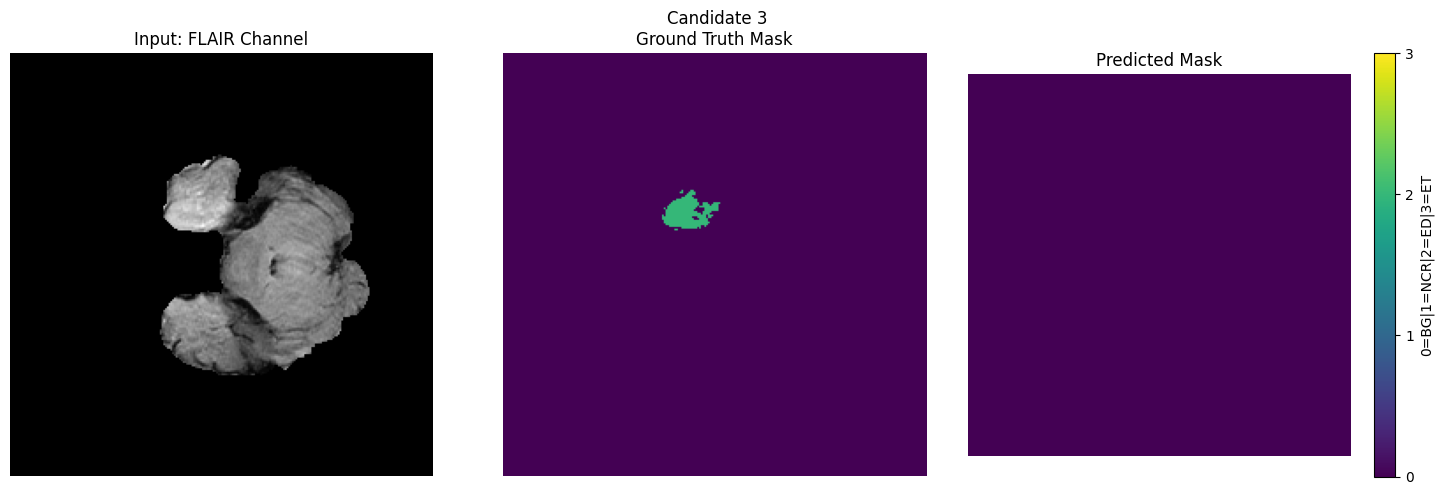


📊 Per-class Dice Scores (Candidate 3):
   Class 0 (Background               ): Dice = 0.9965
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 0.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


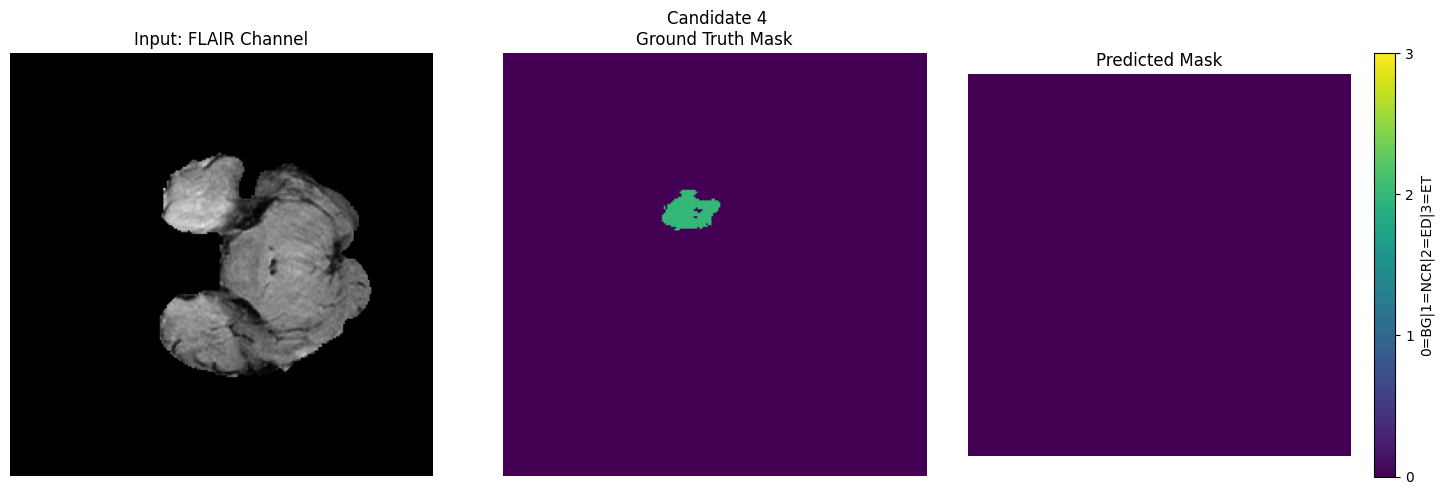


📊 Per-class Dice Scores (Candidate 4):
   Class 0 (Background               ): Dice = 0.9958
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 0.0000
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


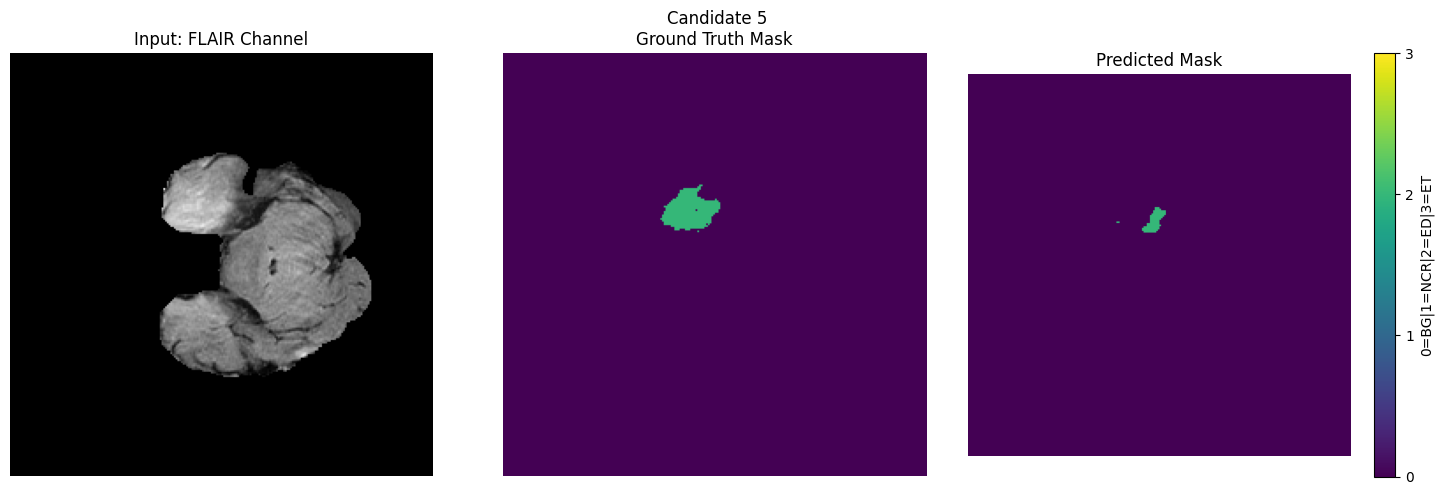


📊 Per-class Dice Scores (Candidate 5):
   Class 0 (Background               ): Dice = 0.9959
   Class 1 (NCR (Core)               ): Dice = 1.0000
   Class 2 (Oedema (ED)              ): Dice = 0.3008
   Class 3 (Enhancing Tumour (ET)    ): Dice = 1.0000


In [ ]:
import matplotlib.pyplot as plt

found_count = 0
MAX_TO_SHOW = 5

for val_images, val_masks in val_dataset_final:
    for i in range(val_images.shape[0]):
        y_true_onehot = val_masks[i:i+1]
        y_true = np.argmax(y_true_onehot[0], axis=-1)

        if np.sum(y_true > 0) > 100:
            x_sample = val_images[i:i+1]
            y_pred_prob = model.predict(x_sample, verbose=0)
            y_pred = np.argmax(y_pred_prob[0], axis=-1)
            flair_channel = x_sample[0, :, :, 3]

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(flair_channel, cmap='gray')
            axes[0].set_title('Input: FLAIR Channel')
            axes[0].axis('off')
            axes[1].imshow(y_true, cmap='viridis', vmin=0, vmax=3)
            axes[1].set_title('Ground Truth Mask')
            axes[1].axis('off')
            im = axes[2].imshow(y_pred, cmap='viridis', vmin=0, vmax=3)
            axes[2].set_title('Predicted Mask')
            axes[2].axis('off')
            plt.colorbar(im, ax=axes[2], ticks=[0,1,2,3], label='0=BG|1=NCR|2=ED|3=ET')
            plt.suptitle(f'Candidate {found_count+1}')
            plt.tight_layout()
            plt.show()

            print(f"\n📊 Per-class Dice Scores (Candidate {found_count+1}):")
            CLASS_NAMES = ['Background', 'NCR (Core)', 'Oedema (ED)', 'Enhancing Tumour (ET)']
            for c in range(4):
                true_c = (y_true == c).astype(float)
                pred_c = (y_pred == c).astype(float)
                intersection = np.sum(true_c * pred_c)
                dice = (2 * intersection + 1e-6) / (np.sum(true_c) + np.sum(pred_c) + 1e-6)
                print(f"   Class {c} ({CLASS_NAMES[c]:25s}): Dice = {dice:.4f}")

            found_count += 1
            if found_count >= MAX_TO_SHOW:
                break
    if found_count >= MAX_TO_SHOW:
        break